<h2> Import Libraries</h3>

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<h2>Insert Dataset</h2>

In [3]:
df=pd.read_csv("../data/raw_data/loan_data_raw.csv")

<h2> Inspect Data</h2>

In [10]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [7]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [8]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [23]:
print(df.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [9]:
df.shape

(614, 13)

In [47]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome
count,614.000000,614.000000,592.000000,600.00000,564.000000,614.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199,7024.705081
std,6109.041673,2926.248369,85.587325,65.12041,0.364878,6458.663872
min,150.000000,0.000000,9.000000,12.00000,0.000000,1442.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000,4166.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000,5416.500000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000,7521.750000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000,81000.000000


In [18]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

<h3>Categoral Features</h3>

In [45]:
categorical_columns=df.select_dtypes(include=['object','str']).columns

for i in categorical_columns:
    missing_count = df[i].isnull().sum()
    missing_pct = df[i].isnull().mean() * 100

    if missing_pct > 0:
        print(f"{i}: {missing_count} null values , missing percentage({missing_pct:.2f}%)")

Gender: 13 null values , missing percentage(2.12%)
Married: 3 null values , missing percentage(0.49%)
Dependents: 15 null values , missing percentage(2.44%)
Self_Employed: 32 null values , missing percentage(5.21%)


<h3>Gender Data Distribution</h3>

In [66]:
gender_distribution=df['Gender'].value_counts(normalize=True)*100
gender_distribution.reset_index()

,Gender,proportion
0,Male,81.364393
1,Female,18.635607


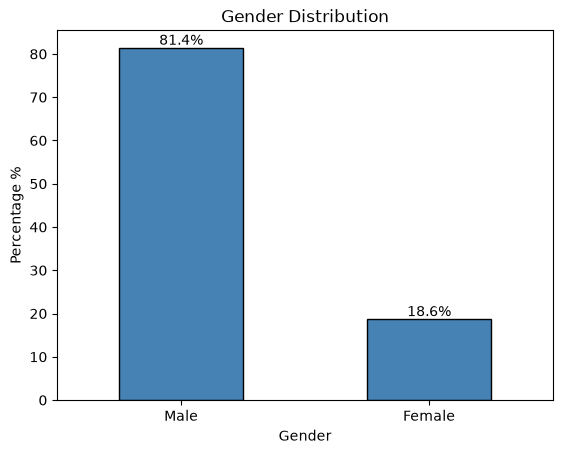

In [62]:
ax = gender_distribution.plot(kind='bar' , color='steelblue', edgecolor='black')
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.title('Gender Distribution')
plt.ylabel('Percentage %')
plt.xticks(rotation=0)
plt.show()

<h3>Marriage Data Distribution</h3>

In [68]:
Marriage_distribution=df['Married'].value_counts(normalize=True)*100
Marriage_distribution.reset_index()

,Married,proportion
0,Yes,65.139116
1,No,34.860884


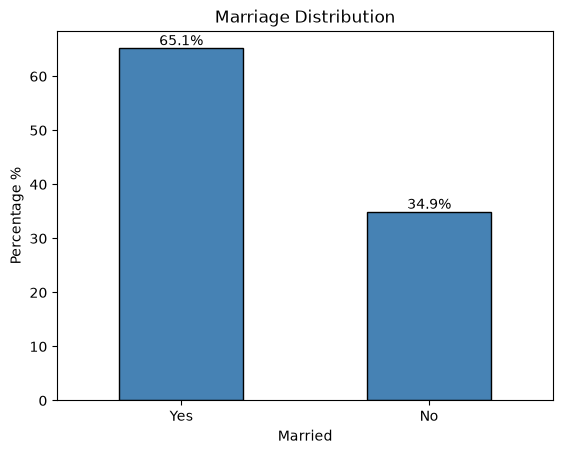

In [69]:
ax = Marriage_distribution.plot(kind='bar' , color='steelblue', edgecolor='black')
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.title('Marriage Distribution')
plt.ylabel('Percentage %')
plt.xticks(rotation=0)
plt.show()

<h3>Dependents Data Distribution</h3>

In [12]:
Dependents_distribution=df['Dependents'].value_counts(normalize=True)*100
Dependents_distribution.reset_index()

,Dependents,proportion
0,0,57.595993
1,1,17.028381
2,2,16.861436
3,3+,8.514190


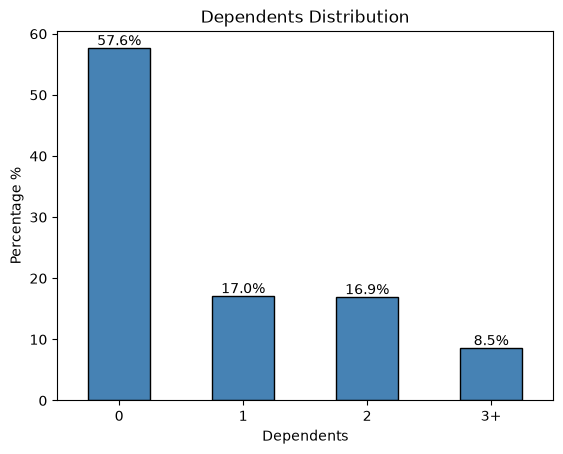

In [13]:
ax = Dependents_distribution.plot(kind='bar' , color='steelblue', edgecolor='black')
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.title('Dependents Distribution')
plt.ylabel('Percentage %')
plt.xticks(rotation=0)
plt.show()

<h3>Self Employed Data Distribution</h3>

In [14]:
Self_Employed_distribution=df['Self_Employed'].value_counts(normalize=True)*100
Self_Employed_distribution.reset_index()

,Self_Employed,proportion
0,No,85.910653
1,Yes,14.089347


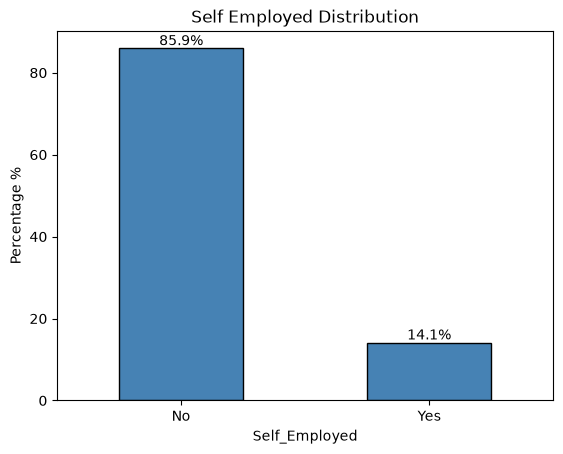

In [15]:
ax=Self_Employed_distribution.plot(kind='bar' , color='steelblue', edgecolor='black')
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.title('Self Employed Distribution')
plt.ylabel('Percentage %')
plt.xticks(rotation=0)
plt.show()

<h3>Numeric Features</h3>

In [6]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for i in numeric_columns:
    missing_count = df[i].isnull().sum()
    missing_pct = df[i].isnull().mean() * 100

    if missing_pct > 0:
        print(f"{i}: {missing_count} null values, missing percentage({missing_pct:.2f}%)")

LoanAmount: 22 null values, missing percentage(3.58%)
Loan_Amount_Term: 14 null values, missing percentage(2.28%)
Credit_History: 50 null values, missing percentage(8.14%)


In [7]:
LoanAmount_distribution = df['LoanAmount'].describe()
print(LoanAmount_distribution)

count    592.000000
mean     146.412162
std       85.587325
min        9.000000
25%      100.000000
50%      128.000000
75%      168.000000
max      700.000000
Name: LoanAmount, dtype: float64
